# Customer Shopping Behavior Analysis — Online Retail Dataset

## Dataset
This analysis uses the **UCI "Online Retail" dataset**: real transaction-level
data from a UK-based online gift retailer, covering **01-Dec-2010 to
09-Dec-2011**. Each row is one line item on an invoice (customer, product,
quantity, price, date, country) — many customers are wholesalers who buy in
bulk, not typical single-item shoppers.

## Business Problem
> Which customers generate the most revenue and show the strongest loyalty
> signals, and what does their purchasing behavior (recency, frequency,
> order value, country, product mix) tell us about how to retain and grow
> the highest-value segments?

This notebook covers data cleaning, exploratory analysis, and an RFM
(Recency/Frequency/Monetary) segmentation that feeds the SQL analysis and
Power BI dashboard.

## 1. Load & Inspect Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9,5)

df = pd.read_csv('online_retail.csv', parse_dates=['InvoiceDate'])
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


In [3]:
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,NaN,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


## 2. Data Cleaning

Real transactional data needs several fixes before it can be trusted:
- Missing `CustomerID` → can't attribute the purchase to a customer, so these rows are unusable for customer-level analysis.
- Cancelled orders (`InvoiceNo` starting with `C`) → represent returns, not purchases.
- Non-positive `Quantity` or `UnitPrice` → data entry errors or return line items.
- Duplicate rows → exact duplicate transactions.


In [4]:
print("Missing CustomerID:", df['CustomerID'].isnull().sum())
print("Missing Description:", df['Description'].isnull().sum())
print("Cancelled orders (InvoiceNo starts with 'C'):", df['InvoiceNo'].astype(str).str.startswith('C').sum())
print("Non-positive Quantity:", (df['Quantity'] <= 0).sum())
print("Non-positive UnitPrice:", (df['UnitPrice'] <= 0).sum())
print("Exact duplicate rows:", df.duplicated().sum())

Missing CustomerID: 135080
Missing Description: 1454
Cancelled orders (InvoiceNo starts with 'C'): 9288
Non-positive Quantity: 10624
Non-positive UnitPrice: 2517


Exact duplicate rows: 5268


In [5]:
df_clean = df.copy()

# Drop rows with no customer attached
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remove cancellations
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Keep only real, positive-value purchases
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Drop exact duplicates
df_clean = df_clean.drop_duplicates()

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean), f"({100*(len(df)-len(df_clean))/len(df):.1f}%)")

Rows before cleaning: 541909
Rows after cleaning: 392692
Rows removed: 149217 (27.5%)


In [6]:
# Standardize column names to snake_case and add total line revenue
df_clean.columns = ['invoice_no','stock_code','description','quantity',
                     'invoice_date','unit_price','customer_id','country']
df_clean['total_price'] = df_clean['quantity'] * df_clean['unit_price']
df_clean.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3. Exploratory Data Analysis

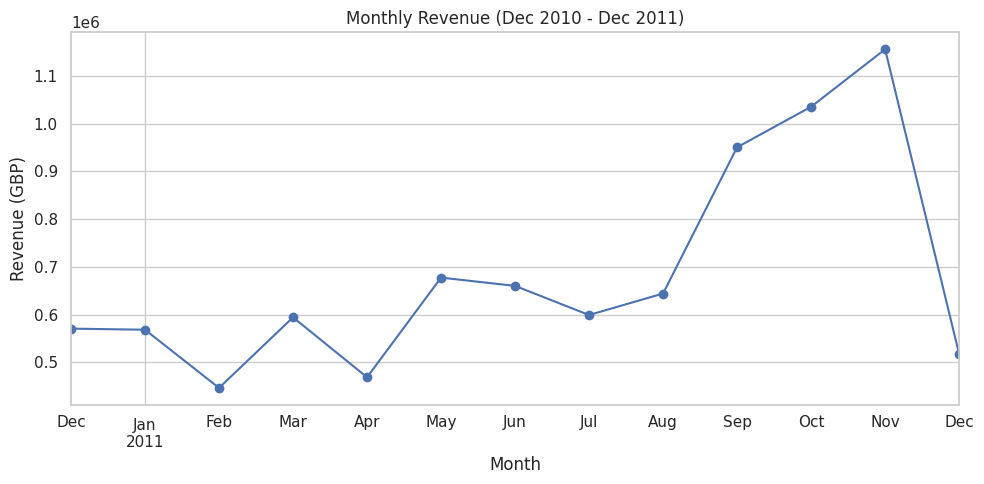

In [7]:
monthly_revenue = df_clean.set_index('invoice_date').resample('MS')['total_price'].sum()
fig, ax = plt.subplots(figsize=(10,5))
monthly_revenue.plot(marker='o', ax=ax, color='#4C72B0')
ax.set_title('Monthly Revenue (Dec 2010 - Dec 2011)')
ax.set_ylabel('Revenue (GBP)')
ax.set_xlabel('Month')
plt.tight_layout()
plt.savefig('charts/monthly_revenue_trend.png', dpi=120)
plt.show()

/tmp/ipykernel_491/3369535271.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, palette='viridis')


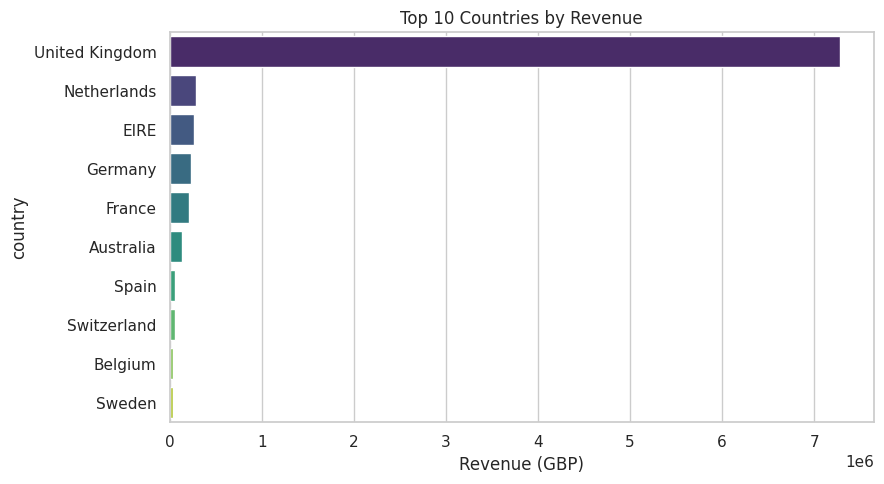

In [8]:
top_countries = df_clean.groupby('country')['total_price'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, palette='viridis')
ax.set_title('Top 10 Countries by Revenue')
ax.set_xlabel('Revenue (GBP)')
plt.tight_layout()
plt.savefig('charts/top_countries_revenue.png', dpi=120)
plt.show()

/tmp/ipykernel_491/2837909567.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, ax=ax, palette='mako')


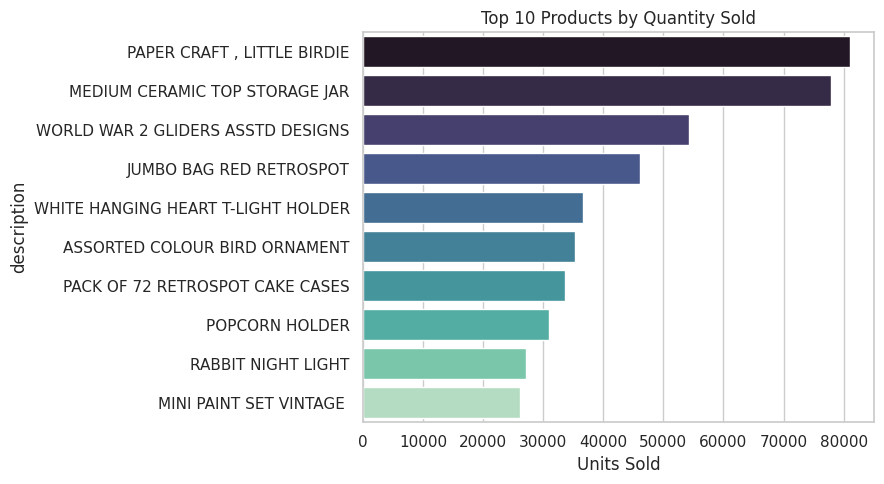

In [9]:
top_products = df_clean.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(x=top_products.values, y=top_products.index, ax=ax, palette='mako')
ax.set_title('Top 10 Products by Quantity Sold')
ax.set_xlabel('Units Sold')
plt.tight_layout()
plt.savefig('charts/top_products_quantity.png', dpi=120)
plt.show()

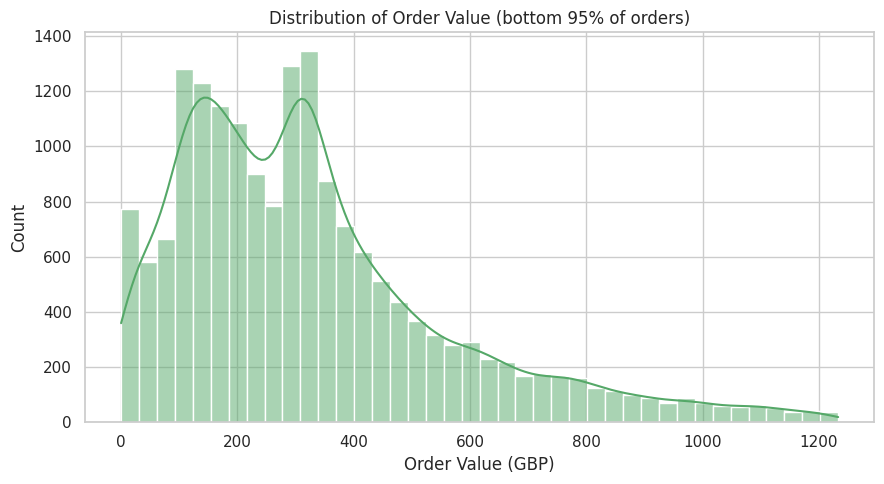

In [10]:
order_value = df_clean.groupby('invoice_no')['total_price'].sum()
fig, ax = plt.subplots()
sns.histplot(order_value[order_value < order_value.quantile(0.95)], bins=40, kde=True, ax=ax, color='#55A868')
ax.set_title('Distribution of Order Value (bottom 95% of orders)')
ax.set_xlabel('Order Value (GBP)')
plt.tight_layout()
plt.savefig('charts/order_value_distribution.png', dpi=120)
plt.show()

Customers: 4338
Median orders per customer: 2.0
Mean orders per customer: 4.27


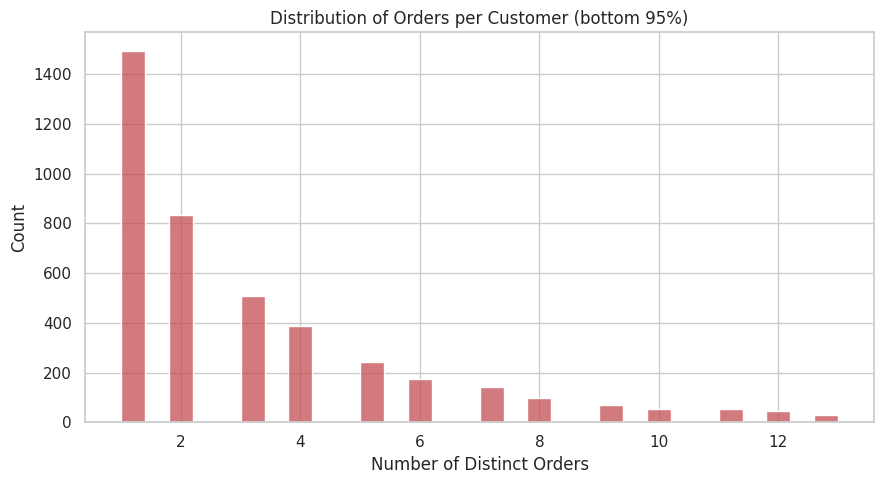

In [11]:
orders_per_customer = df_clean.groupby('customer_id')['invoice_no'].nunique()
print("Customers:", df_clean['customer_id'].nunique())
print("Median orders per customer:", orders_per_customer.median())
print("Mean orders per customer:", round(orders_per_customer.mean(),2))
fig, ax = plt.subplots()
sns.histplot(orders_per_customer[orders_per_customer <= orders_per_customer.quantile(0.95)], bins=30, ax=ax, color='#C44E52')
ax.set_title('Distribution of Orders per Customer (bottom 95%)')
ax.set_xlabel('Number of Distinct Orders')
plt.tight_layout()
plt.savefig('charts/orders_per_customer_distribution.png', dpi=120)
plt.show()

**EDA takeaways** *(numbers computed live above)*:
- Revenue is heavily concentrated in the UK, which dominates both order count and revenue — international countries are a long tail.
- Order values are right-skewed: most orders are modest, but a meaningful number of large wholesale-style orders pull the average up, which is exactly the kind of customer RFM segmentation is built to separate out.
- Most customers place relatively few distinct orders across the year, so the small group of highly frequent buyers stands out clearly once segmented.

## 4. RFM Segmentation

This dataset has real dates and invoices, so RFM is computed directly rather than approximated:
- **Recency** → days between the customer's last purchase and the day after the dataset's last recorded transaction
- **Frequency** → number of distinct invoices (orders) placed
- **Monetary** → total amount spent across all orders


In [12]:
snapshot_date = df_clean['invoice_date'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('customer_id').agg(
    recency=('invoice_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('invoice_no', 'nunique'),
    monetary=('total_price', 'sum')
).reset_index()

rfm.describe()

,customer_id,recency,frequency,monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


In [13]:
# Score 1-4 on each dimension (4 = best). Lower recency is better, so it's inverted.
rfm['R_score'] = pd.qcut(rfm['recency'].rank(method='first'), 4, labels=[4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)

rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def segment_customer(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal'
    elif score >= 6:
        return 'Potential Loyalist'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Needs Attention'

rfm['rfm_segment'] = rfm['RFM_score'].apply(segment_customer)
rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,rfm_segment
0,12346,326,1,77183.60,1,1,4,6,Potential Loyalist
1,12347,2,7,4310.00,4,4,4,12,Champions
2,12348,75,4,1797.24,2,3,4,9,Loyal
3,12349,19,1,1757.55,3,1,4,8,Loyal
4,12350,310,1,334.40,1,1,2,4,At Risk


In [14]:
segment_summary = rfm.groupby('rfm_segment').agg(
    customers=('customer_id','count'),
    avg_recency_days=('recency','mean'),
    avg_frequency=('frequency','mean'),
    avg_monetary=('monetary','mean'),
    total_revenue=('monetary','sum')
).sort_values('total_revenue', ascending=False)
segment_summary['pct_of_customers'] = (100*segment_summary['customers']/segment_summary['customers'].sum()).round(1)
segment_summary['pct_of_revenue'] = (100*segment_summary['total_revenue']/segment_summary['total_revenue'].sum()).round(1)
segment_summary.round(2)

,customers,avg_recency_days,avg_frequency,avg_monetary,total_revenue,pct_of_customers,pct_of_revenue
rfm_segment,,,,,,,
Champions,1260,19.90,9.95,5412.17,6819332.77,29.0,76.7
Loyal,843,52.38,3.25,1250.91,1054519.62,19.4,11.9
Potential Loyalist,940,86.96,1.87,695.67,653931.48,21.7,7.4
At Risk,995,170.95,1.20,312.63,311066.79,22.9,3.5
Needs Attention,300,267.83,1.00,161.19,48358.23,6.9,0.5


/tmp/ipykernel_491/9331585.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_summary['customers'], y=segment_summary.index, ax=ax, palette='crest')


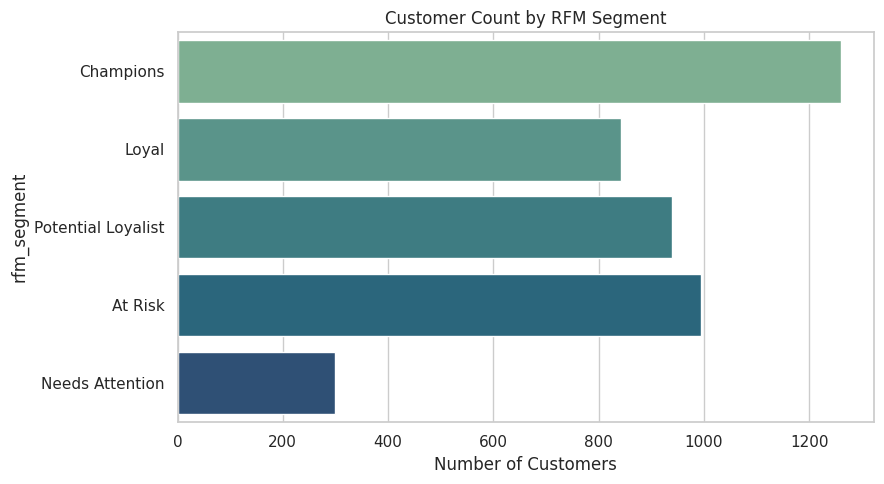

In [15]:
fig, ax = plt.subplots()
sns.barplot(x=segment_summary['customers'], y=segment_summary.index, ax=ax, palette='crest')
ax.set_title('Customer Count by RFM Segment')
ax.set_xlabel('Number of Customers')
plt.tight_layout()
plt.savefig('charts/rfm_segment_counts.png', dpi=120)
plt.show()

/tmp/ipykernel_491/2638942268.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_summary['total_revenue'], y=segment_summary.index, ax=ax, palette='rocket')


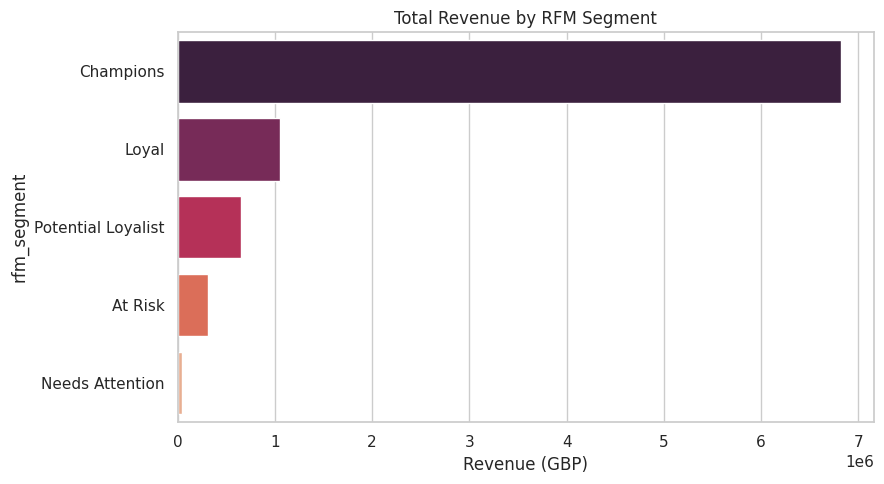

In [16]:
fig, ax = plt.subplots()
sns.barplot(x=segment_summary['total_revenue'], y=segment_summary.index, ax=ax, palette='rocket')
ax.set_title('Total Revenue by RFM Segment')
ax.set_xlabel('Revenue (GBP)')
plt.tight_layout()
plt.savefig('charts/rfm_segment_revenue.png', dpi=120)
plt.show()

## 5. Merge segment back into transaction data & export for SQL / Power BI

In [17]:
df_final = df_clean.merge(rfm[['customer_id','recency','frequency','monetary',
                                  'R_score','F_score','M_score','RFM_score','rfm_segment']],
                            on='customer_id', how='left')

df_final.to_csv('online_retail_cleaned.csv', index=False)
rfm.to_csv('customer_rfm_summary.csv', index=False)
print("Exported online_retail_cleaned.csv:", df_final.shape)
print("Exported customer_rfm_summary.csv:", rfm.shape)

Exported online_retail_cleaned.csv: (392692, 17)
Exported customer_rfm_summary.csv: (4338, 9)


## 6. (Optional) Load into PostgreSQL

Uncomment and fill in your credentials to push the cleaned, segmented data
into Postgres for the SQL analysis step.

In [18]:
# from sqlalchemy import create_engine
#
# username = "myuser"
# password = "mypassword"
# host = "localhost"
# port = "5432"
# database = "retail_analysis"
#
# engine = create_engine(f"postgresql://{username}:{password}@{host}:{port}/{database}")
# df_final.to_sql('online_retail', engine, if_exists='replace', index=False)
# rfm.to_sql('customer_rfm', engine, if_exists='replace', index=False)
# print("Loaded into PostgreSQL as tables 'online_retail' and 'customer_rfm'")

## 7. Summary of Findings

In [19]:
print("Date range:", df_clean['invoice_date'].min().date(), "to", df_clean['invoice_date'].max().date())
print("Total customers:", df_clean['customer_id'].nunique())
print("Total orders:", df_clean['invoice_no'].nunique())
print("Total revenue: GBP", round(df_clean['total_price'].sum(), 2))
print("Average order value: GBP", round(order_value.mean(), 2))
print()
print("Revenue and customer share by RFM segment:")
print(segment_summary[['customers','pct_of_customers','total_revenue','pct_of_revenue']])
print()
print("Top country by revenue:", top_countries.index[0], "- GBP", round(top_countries.iloc[0],2))

Date range: 2010-12-01 to 2011-12-09
Total customers: 4338
Total orders: 18532
Total revenue: GBP 8887208.89
Average order value: GBP 479.56

Revenue and customer share by RFM segment:
                    customers  pct_of_customers  total_revenue  pct_of_revenue
rfm_segment                                                                   
Champions                1260              29.0    6819332.770            76.7
Loyal                     843              19.4    1054519.621            11.9
Potential Loyalist        940              21.7     653931.482             7.4
At Risk                   995              22.9     311066.791             3.5
Needs Attention           300               6.9      48358.230             0.5

Top country by revenue: United Kingdom - GBP 7285024.64
